<p align="center">
  <img src="https://i0.wp.com/www.tiempodecine.co/web/wp-content/uploads/2015/11/Robert-De-Niro-in-Taxi-Driver-1976.jpg?resize=750%2C375&ssl=1" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Evaluación de Modelos de Clustering para Optimización de Flotas</span>
  </p>
</div>

# FASE 5: Evaluación (CRISP-DM)

## Propósito de la Fase de Evaluación

En esta quinta fase del proceso CRISP-DM, evaluamos los **modelos de clustering** desarrollados en la fase anterior para:

### **Objetivos de Evaluación:**
1. **Validar la calidad** de los clusters generados
2. **Comparar diferentes algoritmos** (K-Means, DBSCAN, Jerárquico)
3. **Interpretar los resultados** desde una perspectiva de negocio
4. **Identificar insights accionables** para optimización de flotas

### **Métricas de Evaluación:**
- **Silhouette Score**: Mide la cohesión y separación de clusters (-1 a 1, mayor es mejor)
- **Davies-Bouldin Index**: Mide la similaridad entre clusters (menor es mejor)
- **Calinski-Harabasz Score**: Ratio de dispersión entre/dentro clusters (mayor es mejor)
- **Inertia**: Suma de distancias cuadradas a centroides (solo K-Means)

### **Análisis de Negocio:**
- Caracterización de cada cluster
- Patrones de demanda por zona
- Recomendaciones estratégicas
- Validación contra objetivos de negocio

# 1. Carga de Librerías

In [35]:
# Verificar e instalar dependencias
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')
    
    # Librerías base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import joblib
    import json
    from pathlib import Path
    
    # Machine Learning
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
    from sklearn.decomposition import PCA
    from sklearn.metrics import (
        silhouette_score, 
        davies_bouldin_score, 
        calinski_harabasz_score,
        silhouette_samples
    )
    from scipy.cluster.hierarchy import dendrogram, linkage
    from scipy.spatial.distance import cdist
    
    print("✓ Todas las dependencias cargadas exitosamente")
    
except ImportError as e:
    print(f"Instalando dependencias faltantes...")
    %pip install --quiet scikit-learn scipy matplotlib seaborn joblib
    print("✓ Instalación completada")

✓ Todas las dependencias cargadas exitosamente


# 2. Configuración

In [36]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Crear directorio para resultados si no existe
Path('evaluation_results').mkdir(exist_ok=True)

print("✓ Configuración completada")

✓ Configuración completada


# 3. Carga de Modelos y Datos

Cargamos los modelos entrenados en la Fase 4 (Modeling) y los datos preparados.

In [37]:
print("="*60)
print("CARGANDO MODELOS Y DATOS")
print("="*60)

# Cargar datos preparados
zones_df = pd.read_parquet('data_prep/zone_features_scaled.parquet')
print(f"✓ Datos cargados: {zones_df.shape}")

# Preparar features para evaluación (excluir zone_id y total_data_length)
feature_cols = [col for col in zones_df.columns if col not in ['zone_id', 'total_data_length']]
X = zones_df[feature_cols].values
print(f"✓ Features preparadas: {X.shape}")

# Cargar modelos entrenados
try:
    kmeans_model = joblib.load('models/kmeans_model.pkl')
    print("✓ Modelo K-Means cargado")
except:
    print("⚠ Modelo K-Means no encontrado")
    kmeans_model = None

try:
    dbscan_model = joblib.load('models/dbscan_model.pkl')
    print("✓ Modelo DBSCAN cargado")
except:
    print("⚠ Modelo DBSCAN no encontrado")
    dbscan_model = None

try:
    hierarchical_model = joblib.load('models/hierarchical_model.pkl')
    print("✓ Modelo Jerárquico cargado")
except:
    print("⚠ Modelo Jerárquico no encontrado")
    hierarchical_model = None

print("\n" + "="*60)

CARGANDO MODELOS Y DATOS
✓ Datos cargados: (247, 21)
✓ Features preparadas: (247, 19)
✓ Modelo K-Means cargado
✓ Modelo DBSCAN cargado
✓ Modelo Jerárquico cargado



# 4. Evaluación de Métricas de Clustering

## 4.1 Función de Evaluación Completa

In [38]:
def evaluate_clustering_model(X, labels, model_name, model=None):
    """
    Evalúa un modelo de clustering con múltiples métricas.
    
    Parameters:
    -----------
    X : array-like
        Features normalizadas
    labels : array-like
        Etiquetas de cluster asignadas
    model_name : str
        Nombre del modelo
    model : object, optional
        Modelo entrenado (para métricas específicas)
    
    Returns:
    --------
    dict : Diccionario con métricas de evaluación
    """
    results = {
        'model_name': model_name,
        'n_clusters': len(np.unique(labels[labels != -1])),  # Excluir outliers (-1)
        'n_outliers': np.sum(labels == -1),
        'n_samples': len(labels)
    }
    
    # Filtrar outliers para métricas (DBSCAN puede tener -1)
    mask = labels != -1
    X_filtered = X[mask]
    labels_filtered = labels[mask]
    
    # Solo calcular métricas si hay al menos 2 clusters
    if results['n_clusters'] >= 2 and len(X_filtered) > 0:
        # Silhouette Score
        results['silhouette_score'] = silhouette_score(X_filtered, labels_filtered)
        
        # Davies-Bouldin Index
        results['davies_bouldin_score'] = davies_bouldin_score(X_filtered, labels_filtered)
        
        # Calinski-Harabasz Score
        results['calinski_harabasz_score'] = calinski_harabasz_score(X_filtered, labels_filtered)
        
        # Inertia (solo para K-Means)
        if model is not None and hasattr(model, 'inertia_'):
            results['inertia'] = model.inertia_
        
        # Distribución de clusters
        unique, counts = np.unique(labels_filtered, return_counts=True)
        results['cluster_distribution'] = dict(zip(unique.tolist(), counts.tolist()))
        
    else:
        results['silhouette_score'] = None
        results['davies_bouldin_score'] = None
        results['calinski_harabasz_score'] = None
        results['cluster_distribution'] = {}
    
    return results

print("✓ Función de evaluación definida")

✓ Función de evaluación definida


## 4.2 Evaluación de Todos los Modelos

In [39]:
print("="*60)
print("EVALUACIÓN DE MODELOS DE CLUSTERING")
print("="*60)

evaluation_results = []

# Evaluar K-Means
if kmeans_model is not None:
    print("\nEvaluando K-Means...")
    kmeans_labels = kmeans_model.labels_
    kmeans_eval = evaluate_clustering_model(X, kmeans_labels, "K-Means", kmeans_model)
    evaluation_results.append(kmeans_eval)
    
    print(f"  • Número de clusters: {kmeans_eval['n_clusters']}")
    print(f"  • Silhouette Score: {kmeans_eval['silhouette_score']:.4f}")
    print(f"  • Davies-Bouldin Index: {kmeans_eval['davies_bouldin_score']:.4f}")
    print(f"  • Calinski-Harabasz Score: {kmeans_eval['calinski_harabasz_score']:.2f}")
    if 'inertia' in kmeans_eval:
        print(f"  • Inertia: {kmeans_eval['inertia']:.2f}")

# Evaluar DBSCAN
if dbscan_model is not None:
    print("\nEvaluando DBSCAN...")
    dbscan_labels = dbscan_model.labels_
    dbscan_eval = evaluate_clustering_model(X, dbscan_labels, "DBSCAN", dbscan_model)
    evaluation_results.append(dbscan_eval)
    
    print(f"  • Número de clusters: {dbscan_eval['n_clusters']}")
    print(f"  • Número de outliers: {dbscan_eval['n_outliers']}")
    if dbscan_eval['silhouette_score'] is not None:
        print(f"  • Silhouette Score: {dbscan_eval['silhouette_score']:.4f}")
        print(f"  • Davies-Bouldin Index: {dbscan_eval['davies_bouldin_score']:.4f}")
        print(f"  • Calinski-Harabasz Score: {dbscan_eval['calinski_harabasz_score']:.2f}")

# Evaluar Clustering Jerárquico
if hierarchical_model is not None:
    print("\nEvaluando Clustering Jerárquico...")
    hierarchical_labels = hierarchical_model.labels_
    hierarchical_eval = evaluate_clustering_model(X, hierarchical_labels, "Hierarchical", hierarchical_model)
    evaluation_results.append(hierarchical_eval)
    
    print(f"  • Número de clusters: {hierarchical_eval['n_clusters']}")
    print(f"  • Silhouette Score: {hierarchical_eval['silhouette_score']:.4f}")
    print(f"  • Davies-Bouldin Index: {hierarchical_eval['davies_bouldin_score']:.4f}")
    print(f"  • Calinski-Harabasz Score: {hierarchical_eval['calinski_harabasz_score']:.2f}")

print("\n" + "="*60)

EVALUACIÓN DE MODELOS DE CLUSTERING

Evaluando K-Means...
  • Número de clusters: 8
  • Silhouette Score: 0.2238
  • Davies-Bouldin Index: 1.3550
  • Calinski-Harabasz Score: 35.86
  • Inertia: 2288.84

Evaluando DBSCAN...
  • Número de clusters: 2
  • Número de outliers: 164
  • Silhouette Score: 0.4932
  • Davies-Bouldin Index: 0.8003
  • Calinski-Harabasz Score: 115.11

Evaluando Clustering Jerárquico...
  • Número de clusters: 8
  • Silhouette Score: 0.2202
  • Davies-Bouldin Index: 1.4933
  • Calinski-Harabasz Score: 33.11



## 4.3 Tabla Comparativa de Modelos

In [40]:
# Crear DataFrame comparativo
comparison_df = pd.DataFrame(evaluation_results)

# Seleccionar columnas relevantes para comparación
comparison_cols = [
    'model_name', 
    'n_clusters', 
    'n_outliers',
    'silhouette_score', 
    'davies_bouldin_score', 
    'calinski_harabasz_score'
]

comparison_display = comparison_df[comparison_cols].copy()

print("\n" + "="*80)
print("TABLA COMPARATIVA DE MODELOS")
print("="*80)
print(comparison_display.to_string(index=False))
print("="*80)

# Guardar resultados
comparison_df.to_csv('evaluation_results/model_comparison.csv', index=False)
print("\n✓ Resultados guardados en 'evaluation_results/model_comparison.csv'")


TABLA COMPARATIVA DE MODELOS
  model_name  n_clusters  n_outliers  silhouette_score  davies_bouldin_score  calinski_harabasz_score
     K-Means           8           0             0.224                 1.355                   35.863
      DBSCAN           2         164             0.493                 0.800                  115.108
Hierarchical           8           0             0.220                 1.493                   33.113

✓ Resultados guardados en 'evaluation_results/model_comparison.csv'


## 4.4 Visualización de Métricas

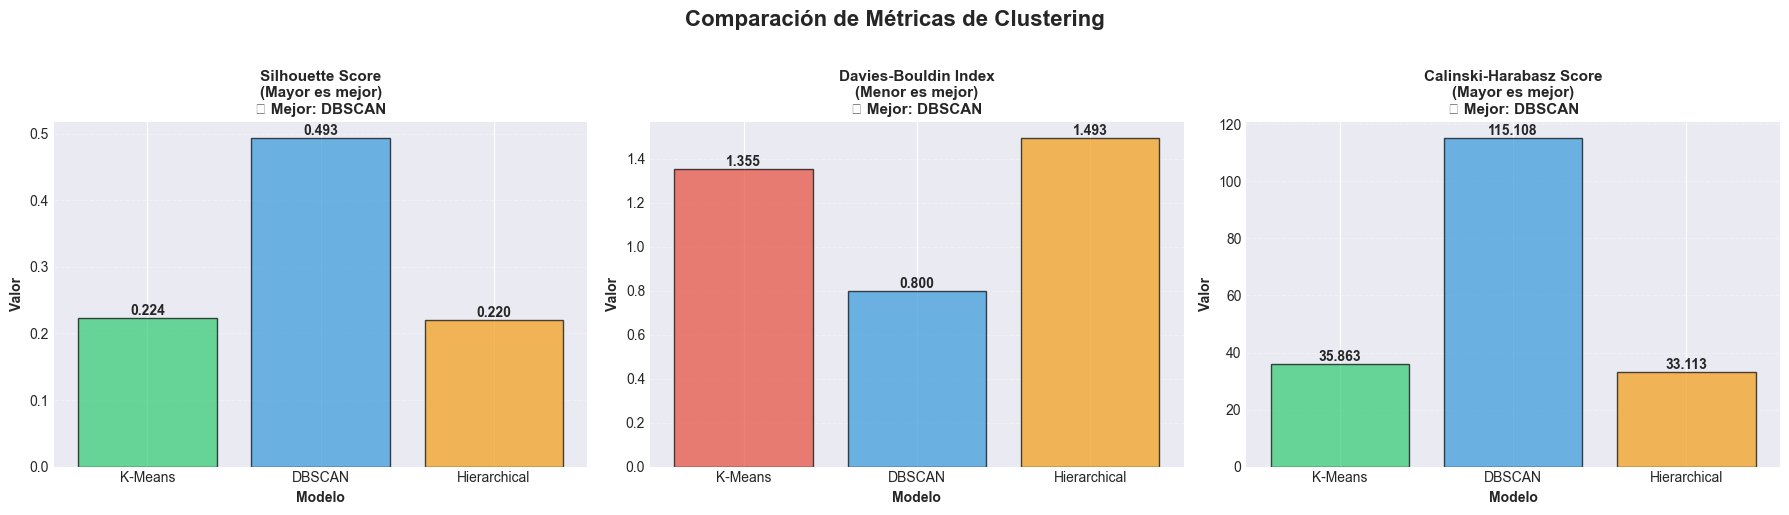

✓ Gráfico guardado en 'evaluation_results/metrics_comparison.png'


In [41]:
# Preparar datos para visualización
metrics_to_plot = [
    ('silhouette_score', 'Silhouette Score\n(Mayor es mejor)', True),
    ('davies_bouldin_score', 'Davies-Bouldin Index\n(Menor es mejor)', False),
    ('calinski_harabasz_score', 'Calinski-Harabasz Score\n(Mayor es mejor)', True)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Métricas de Clustering', fontsize=16, fontweight='bold', y=1.02)

for idx, (metric, title, higher_better) in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Filtrar modelos con valores válidos
    plot_data = comparison_df[comparison_df[metric].notna()]
    
    if len(plot_data) > 0:
        # Crear gráfico de barras
        colors = ['#2ecc71' if higher_better else '#e74c3c', '#3498db', '#f39c12']
        bars = ax.bar(plot_data['model_name'], plot_data[metric], 
                      color=colors[:len(plot_data)], alpha=0.7, edgecolor='black')
        
        # Añadir valores sobre las barras
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontweight='bold')
        
        # Resaltar el mejor modelo
        if higher_better:
            best_idx = plot_data[metric].idxmax()
        else:
            best_idx = plot_data[metric].idxmin()
        
        best_model = plot_data.loc[best_idx, 'model_name']
        ax.set_title(f"{title}\n🏆 Mejor: {best_model}", fontsize=11, fontweight='bold')
        
        ax.set_xlabel('Modelo', fontweight='bold')
        ax.set_ylabel('Valor', fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    else:
        ax.text(0.5, 0.5, 'No hay datos disponibles', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_results/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado en 'evaluation_results/metrics_comparison.png'")

# 5. Análisis de Silhouette por Cluster

El análisis de Silhouette nos permite evaluar la calidad de cada cluster individualmente.

ANÁLISIS DE SILHOUETTE POR CLUSTER

K-Means:


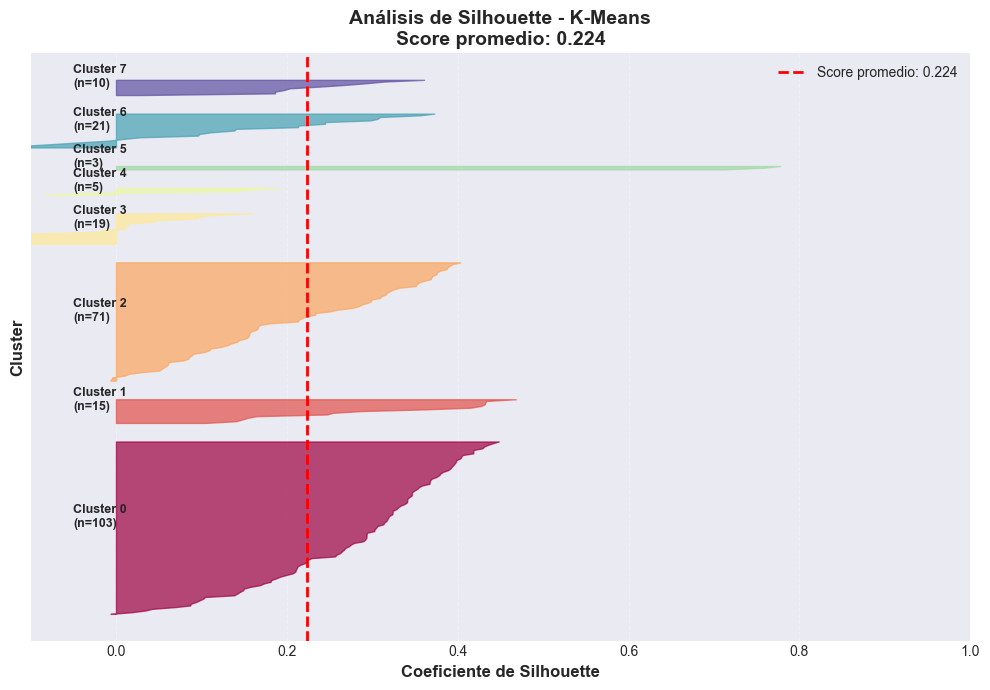


DBSCAN:


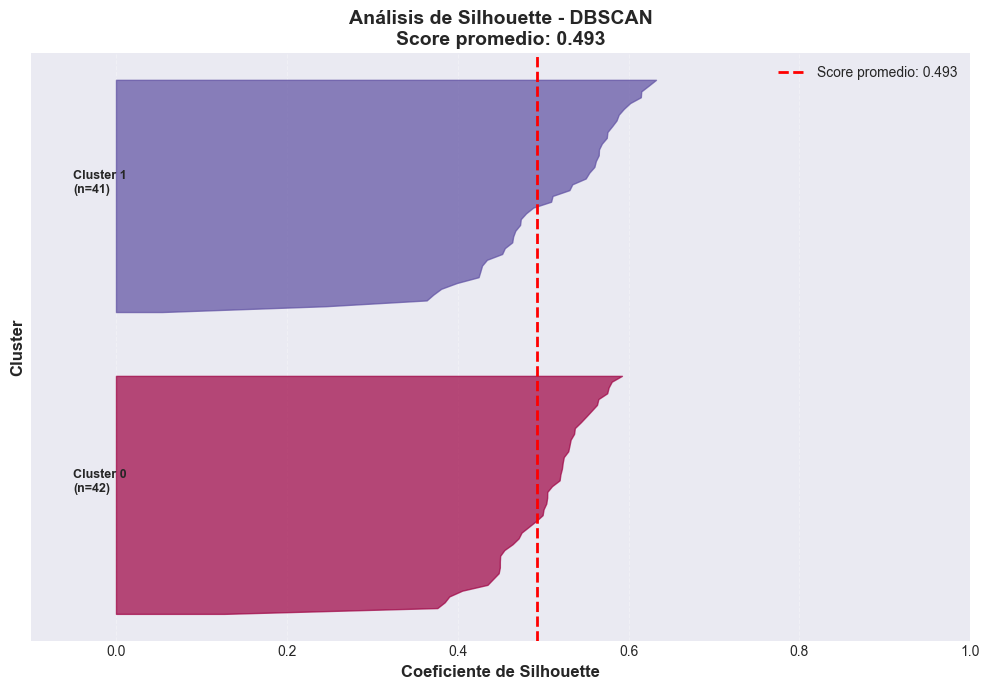


Clustering Jerárquico:


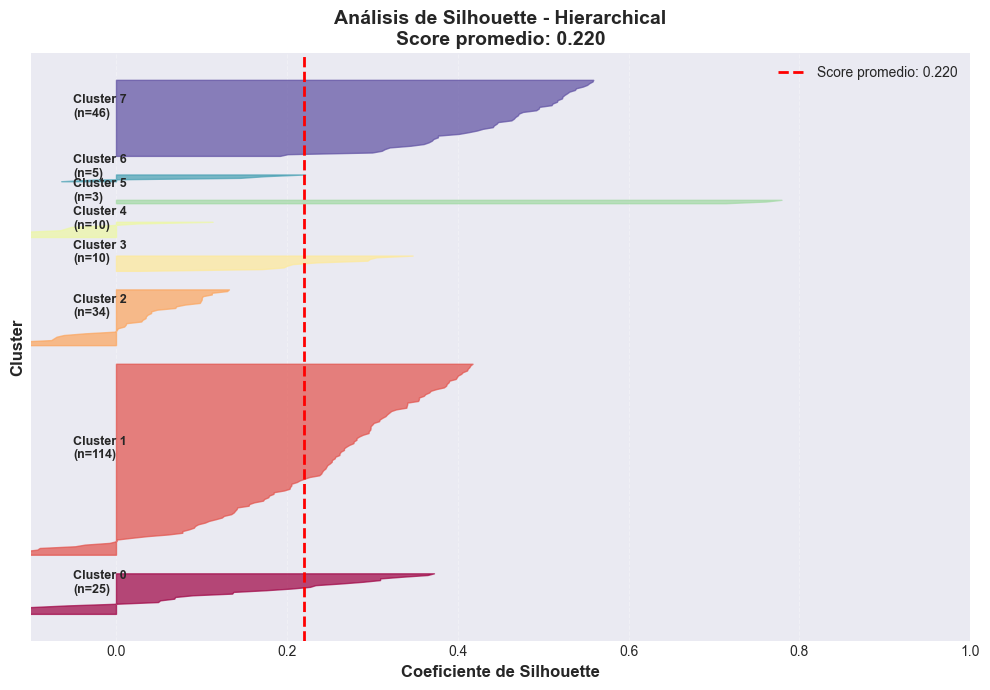

In [42]:
def plot_silhouette_analysis(X, labels, model_name):
    """
    Crea un gráfico de análisis de Silhouette por cluster.
    """
    # Filtrar outliers
    mask = labels != -1
    X_filtered = X[mask]
    labels_filtered = labels[mask]
    
    n_clusters = len(np.unique(labels_filtered))
    
    if n_clusters < 2:
        print(f"⚠ {model_name}: No hay suficientes clusters para análisis de Silhouette")
        return
    
    # Calcular Silhouette scores
    silhouette_avg = silhouette_score(X_filtered, labels_filtered)
    sample_silhouette_values = silhouette_samples(X_filtered, labels_filtered)
    
    # Crear figura
    fig, ax = plt.subplots(figsize=(10, 7))
    
    y_lower = 10
    colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters))
    
    for i, color in zip(range(n_clusters), colors):
        # Valores de Silhouette para cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[labels_filtered == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        # Etiquetar cluster
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}\n(n={size_cluster_i})',
               fontsize=9, fontweight='bold')
        
        y_lower = y_upper + 10
    
    ax.set_title(f'Análisis de Silhouette - {model_name}\nScore promedio: {silhouette_avg:.3f}',
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Coeficiente de Silhouette', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cluster', fontsize=12, fontweight='bold')
    
    # Línea vertical para score promedio
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2,
              label=f'Score promedio: {silhouette_avg:.3f}')
    ax.legend(loc='best', fontsize=10)
    
    ax.set_yticks([])
    ax.set_xlim([-0.1, 1])
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'evaluation_results/silhouette_{model_name.lower().replace(" ", "_")}.png', 
               dpi=300, bbox_inches='tight')
    plt.show()

# Generar análisis de Silhouette para cada modelo
print("="*60)
print("ANÁLISIS DE SILHOUETTE POR CLUSTER")
print("="*60)

if kmeans_model is not None:
    print("\nK-Means:")
    plot_silhouette_analysis(X, kmeans_labels, "K-Means")

if dbscan_model is not None and dbscan_eval['n_clusters'] >= 2:
    print("\nDBSCAN:")
    plot_silhouette_analysis(X, dbscan_labels, "DBSCAN")

if hierarchical_model is not None:
    print("\nClustering Jerárquico:")
    plot_silhouette_analysis(X, hierarchical_labels, "Hierarchical")

# 6. Perfiles de Clusters

Analizamos las características de cada cluster para interpretación de negocio.

In [43]:
def analyze_cluster_profiles(zones_df, labels, model_name):
    """
    Analiza y visualiza los perfiles de cada cluster.
    """
    # Añadir labels al dataframe
    df_analysis = zones_df.copy()
    df_analysis['cluster'] = labels
    
    # Filtrar outliers si existen
    df_analysis = df_analysis[df_analysis['cluster'] != -1]
    
    if len(df_analysis) == 0:
        print(f"⚠ {model_name}: No hay datos para analizar")
        return None
    
    # Seleccionar features clave para análisis
    key_features = [
        'total_trips', 'avg_pickup_hour', 'peak_hour_concentration_pct',
        'pct_AM_Peak', 'pct_PM_Peak', 'pct_weekend_trips',
        'avg_trip_distance', 'avg_trip_duration', 'avg_fare',
        'pct_yellow_taxi'
    ]
    
    # Calcular estadísticas por cluster
    cluster_profiles = df_analysis.groupby('cluster')[key_features].mean()
    cluster_sizes = df_analysis.groupby('cluster').size()
    
    print(f"\n{'='*80}")
    print(f"PERFILES DE CLUSTERS - {model_name}")
    print(f"{'='*80}")
    
    for cluster_id in cluster_profiles.index:
        print(f"\nCLUSTER {cluster_id} (n={cluster_sizes[cluster_id]} zonas)")
        print("-" * 80)
        
        profile = cluster_profiles.loc[cluster_id]
        
        print(f"  Volumen de viajes (normalizado): {profile['total_trips']:.3f}")
        print(f"  Hora promedio de pickup: {profile['avg_pickup_hour']:.3f}")
        print(f"  Concentración en hora pico: {profile['peak_hour_concentration_pct']:.3f}")
        print(f"  % Viajes AM Peak: {profile['pct_AM_Peak']:.3f}")
        print(f"  % Viajes PM Peak: {profile['pct_PM_Peak']:.3f}")
        print(f"  % Viajes fin de semana: {profile['pct_weekend_trips']:.3f}")
        print(f"  Distancia promedio: {profile['avg_trip_distance']:.3f}")
        print(f"  Duración promedio: {profile['avg_trip_duration']:.3f}")
        print(f"  Tarifa promedio: {profile['avg_fare']:.3f}")
        print(f"  % Taxis amarillos: {profile['pct_yellow_taxi']:.3f}")
    
    print(f"\n{'='*80}")
    
    # Guardar perfiles
    cluster_profiles['cluster_size'] = cluster_sizes
    cluster_profiles.to_csv(f'evaluation_results/cluster_profiles_{model_name.lower().replace(" ", "_")}.csv')
    
    return cluster_profiles, df_analysis

# Analizar perfiles para el mejor modelo (K-Means)
if kmeans_model is not None:
    kmeans_profiles, kmeans_df = analyze_cluster_profiles(zones_df, kmeans_labels, "K-Means")


PERFILES DE CLUSTERS - K-Means

CLUSTER 0 (n=103 zonas)
--------------------------------------------------------------------------------
  Volumen de viajes (normalizado): -0.482
  Hora promedio de pickup: -0.344
  Concentración en hora pico: -0.089
  % Viajes AM Peak: 0.392
  % Viajes PM Peak: -0.312
  % Viajes fin de semana: -0.201
  Distancia promedio: -0.117
  Duración promedio: 0.254
  Tarifa promedio: -0.301
  % Taxis amarillos: -0.284

CLUSTER 1 (n=15 zonas)
--------------------------------------------------------------------------------
  Volumen de viajes (normalizado): 2.880
  Hora promedio de pickup: 0.738
  Concentración en hora pico: -0.506
  % Viajes AM Peak: -0.445
  % Viajes PM Peak: 1.122
  % Viajes fin de semana: -0.377
  Distancia promedio: -0.097
  Duración promedio: -0.580
  Tarifa promedio: -0.285
  % Taxis amarillos: -0.636

CLUSTER 2 (n=71 zonas)
--------------------------------------------------------------------------------
  Volumen de viajes (normalizado): 

## 6.1 Visualización de Perfiles de Clusters

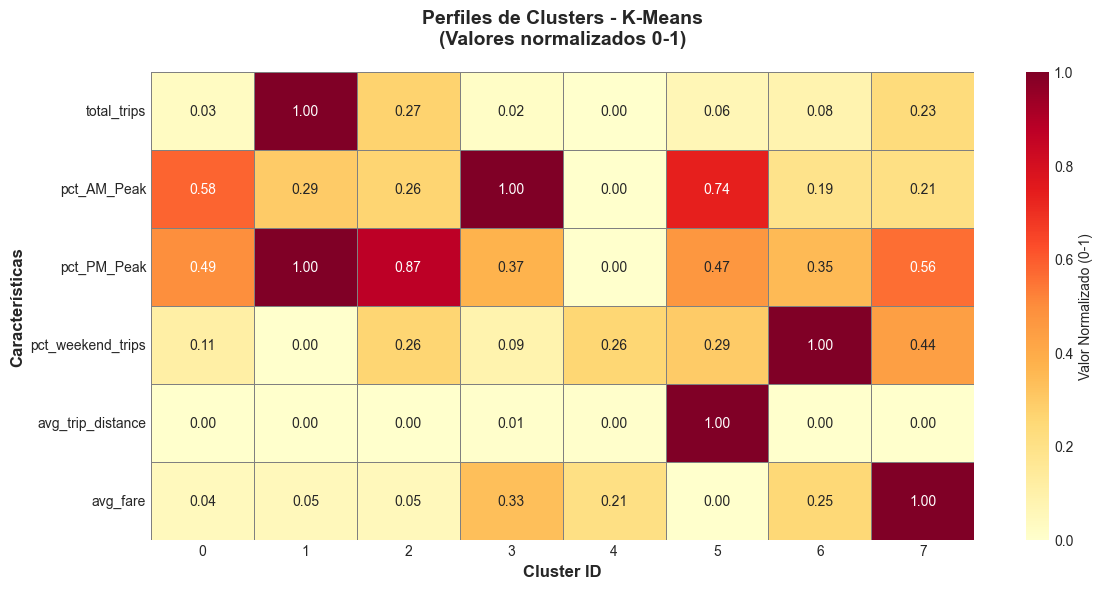

✓ Heatmap guardado en 'evaluation_results/cluster_profiles_heatmap.png'


In [44]:
if kmeans_profiles is not None:
    # Seleccionar features clave para visualización
    viz_features = [
        'total_trips', 'pct_AM_Peak', 'pct_PM_Peak', 
        'pct_weekend_trips', 'avg_trip_distance', 'avg_fare'
    ]
    
    # Crear heatmap de perfiles
    plt.figure(figsize=(12, 6))
    
    # Normalizar para mejor visualización
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    profiles_normalized = pd.DataFrame(
        scaler.fit_transform(kmeans_profiles[viz_features]),
        index=kmeans_profiles.index,
        columns=viz_features
    )
    
    sns.heatmap(profiles_normalized.T, annot=True, fmt='.2f', cmap='YlOrRd', 
               cbar_kws={'label': 'Valor Normalizado (0-1)'},
               linewidths=0.5, linecolor='gray')
    
    plt.title('Perfiles de Clusters - K-Means\n(Valores normalizados 0-1)', 
             fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Cluster ID', fontsize=12, fontweight='bold')
    plt.ylabel('Características', fontsize=12, fontweight='bold')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig('evaluation_results/cluster_profiles_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Heatmap guardado en 'evaluation_results/cluster_profiles_heatmap.png'")

# 7. Visualización en 2D con PCA

Reducimos dimensionalidad con PCA para visualizar los clusters en 2D.

Varianza explicada por componentes PCA:
  PC1: 23.66%
  PC2: 18.02%
  Total: 41.69%


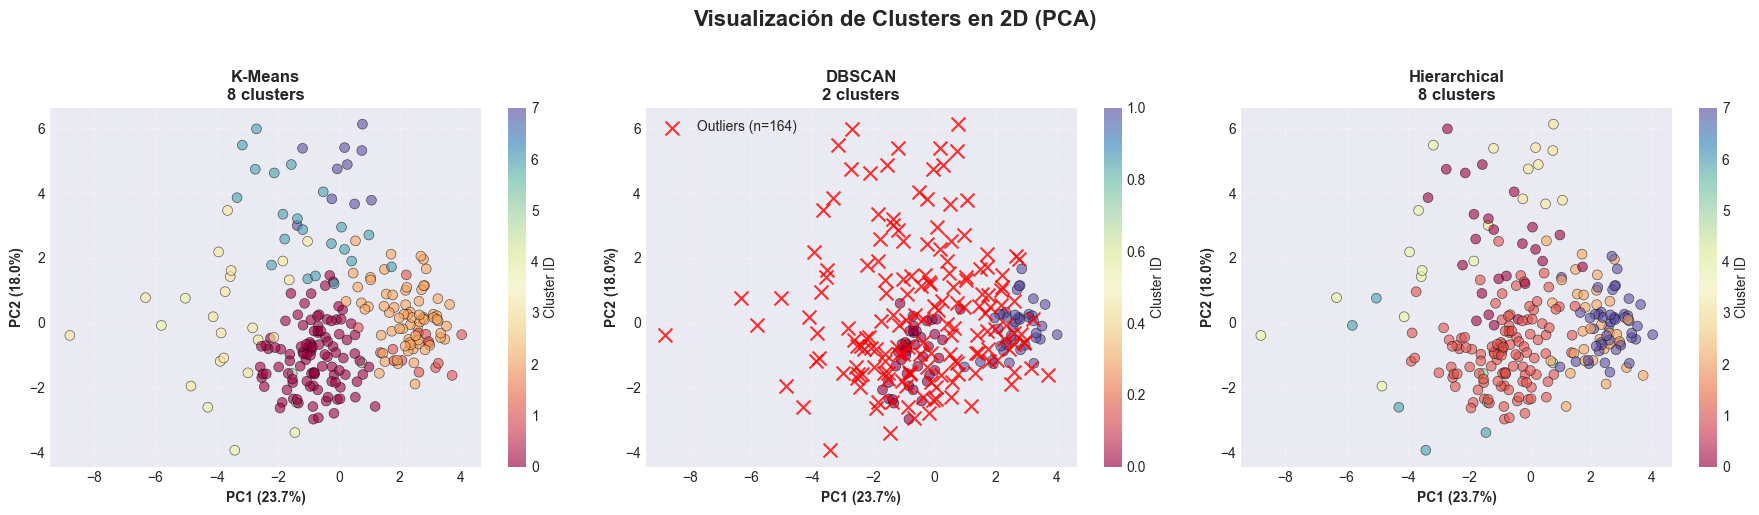

✓ Visualización PCA guardada en 'evaluation_results/clusters_pca_visualization.png'


In [45]:
# Aplicar PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Varianza explicada por componentes PCA:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.2%}")

# Crear visualizaciones para cada modelo
models_to_plot = []
if kmeans_model is not None:
    models_to_plot.append(('K-Means', kmeans_labels))
if dbscan_model is not None and dbscan_eval['n_clusters'] >= 2:
    models_to_plot.append(('DBSCAN', dbscan_labels))
if hierarchical_model is not None:
    models_to_plot.append(('Hierarchical', hierarchical_labels))

if len(models_to_plot) > 0:
    fig, axes = plt.subplots(1, len(models_to_plot), figsize=(6*len(models_to_plot), 5))
    
    if len(models_to_plot) == 1:
        axes = [axes]
    
    for idx, (model_name, labels) in enumerate(models_to_plot):
        ax = axes[idx]
        
        # Separar outliers si existen
        mask_outliers = labels == -1
        mask_clusters = labels != -1
        
        # Plot clusters
        if mask_clusters.any():
            scatter = ax.scatter(X_pca[mask_clusters, 0], X_pca[mask_clusters, 1],
                               c=labels[mask_clusters], cmap='Spectral',
                               s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
            plt.colorbar(scatter, ax=ax, label='Cluster ID')
        
        # Plot outliers
        if mask_outliers.any():
            ax.scatter(X_pca[mask_outliers, 0], X_pca[mask_outliers, 1],
                      c='red', marker='x', s=100, alpha=0.8, 
                      label=f'Outliers (n={mask_outliers.sum()})')
            ax.legend()
        
        ax.set_title(f'{model_name}\n{len(np.unique(labels[mask_clusters]))} clusters',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontweight='bold')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontweight='bold')
        ax.grid(alpha=0.3, linestyle='--')
    
    plt.suptitle('Visualización de Clusters en 2D (PCA)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('evaluation_results/clusters_pca_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualización PCA guardada en 'evaluation_results/clusters_pca_visualization.png'")

# 8. Insights de Negocio

## 8.1 Interpretación de Clusters

In [46]:
def generate_business_insights(cluster_profiles, model_name="K-Means"):
    """
    Genera interpretaciones de negocio para cada cluster.
    """
    insights = {}
    
    print(f"\n{'='*80}")
    print(f"INTERPRETACIÓN DE NEGOCIO - {model_name}")
    print(f"{'='*80}")
    
    for cluster_id in cluster_profiles.index:
        profile = cluster_profiles.loc[cluster_id]
        
        # Clasificar el cluster basado en características
        cluster_type = ""
        recommendations = []
        
        # Análisis de volumen
        if profile['total_trips'] > 0.5:
            cluster_type = "Alta Demanda"
            recommendations.append("Asignar más vehículos en horas pico")
        elif profile['total_trips'] < -0.5:
            cluster_type = "Baja Demanda"
            recommendations.append("Reducir flota o redistribuir a zonas de alta demanda")
        else:
            cluster_type = "Demanda Moderada"
        
        # Análisis temporal
        if profile['pct_AM_Peak'] > 0.5:
            cluster_type += " - Pico Matutino"
            recommendations.append("Incrementar disponibilidad 6-10 AM")
        elif profile['pct_PM_Peak'] > 0.5:
            cluster_type += " - Pico Vespertino"
            recommendations.append("Incrementar disponibilidad 4-8 PM")
        
        # Análisis de fin de semana
        if profile['pct_weekend_trips'] > 0.5:
            cluster_type += " - Zona Recreativa"
            recommendations.append("Reforzar servicio en fines de semana")
        
        # Análisis de distancia
        if profile['avg_trip_distance'] > 0.5:
            recommendations.append("Viajes largos - considerar vehículos más cómodos")
        
        # Análisis de tipo de taxi
        if profile['pct_yellow_taxi'] > 0.5:
            recommendations.append("Zona preferente para taxis amarillos")
        else:
            recommendations.append("Zona preferente para taxis verdes")
        
        insights[cluster_id] = {
            'type': cluster_type,
            'size': int(profile['cluster_size']),
            'recommendations': recommendations
        }
        
        print(f"\n🔹 CLUSTER {cluster_id}: {cluster_type}")
        print(f"   Tamaño: {profile['cluster_size']:.0f} zonas")
        print(f"   Recomendaciones:")
        for rec in recommendations:
            print(f"     • {rec}")
    
    print(f"\n{'='*80}")
    
    # Guardar insights
    with open(f'evaluation_results/business_insights_{model_name.lower().replace(" ", "_")}.json', 'w') as f:
        json.dump(insights, f, indent=2)
    
    return insights

# Generar insights para K-Means
if kmeans_profiles is not None:
    kmeans_insights = generate_business_insights(kmeans_profiles, "K-Means")


INTERPRETACIÓN DE NEGOCIO - K-Means

🔹 CLUSTER 0: Demanda Moderada
   Tamaño: 103 zonas
   Recomendaciones:
     • Zona preferente para taxis verdes

🔹 CLUSTER 1: Alta Demanda - Pico Vespertino
   Tamaño: 15 zonas
   Recomendaciones:
     • Asignar más vehículos en horas pico
     • Incrementar disponibilidad 4-8 PM
     • Zona preferente para taxis verdes

🔹 CLUSTER 2: Demanda Moderada - Pico Vespertino
   Tamaño: 71 zonas
   Recomendaciones:
     • Incrementar disponibilidad 4-8 PM
     • Zona preferente para taxis amarillos

🔹 CLUSTER 3: Baja Demanda - Pico Matutino
   Tamaño: 19 zonas
   Recomendaciones:
     • Reducir flota o redistribuir a zonas de alta demanda
     • Incrementar disponibilidad 6-10 AM
     • Zona preferente para taxis verdes

🔹 CLUSTER 4: Baja Demanda
   Tamaño: 5 zonas
   Recomendaciones:
     • Reducir flota o redistribuir a zonas de alta demanda
     • Zona preferente para taxis verdes

🔹 CLUSTER 5: Demanda Moderada - Pico Matutino
   Tamaño: 3 zonas
   Reco

## 8.2 Recomendaciones Estratégicas

In [47]:
print("\n" + "="*80)
print("RECOMENDACIONES ESTRATÉGICAS GENERALES")
print("="*80)

recommendations = """
📊 RESUMEN EJECUTIVO:

1. OPTIMIZACIÓN DE FLOTAS:
   • Redistribuir vehículos según clusters de demanda identificados
   • Implementar sistema dinámico de asignación basado en patrones temporales
   • Priorizar zonas de alta demanda en horas pico

2. PLANIFICACIÓN TEMPORAL:
   • Ajustar turnos de conductores según patrones AM/PM Peak
   • Crear incentivos para cubrir zonas de baja demanda
   • Implementar tarifas dinámicas por cluster y horario

3. GESTIÓN DE RECURSOS:
   • Establecer estaciones de espera en zonas de alta concentración
   • Optimizar rutas de reposicionamiento entre clusters
   • Balancear distribución Yellow/Green según preferencias zonales

4. MONITOREO Y MEJORA CONTINUA:
   • Implementar dashboard de monitoreo por cluster
   • Revisar y actualizar clusters mensualmente
   • Medir KPIs: tiempo de espera, utilización de flota, satisfacción

5. PRÓXIMOS PASOS:
   • Validar clusters con datos históricos adicionales
   • Realizar prueba piloto en cluster de alta demanda
   • Desarrollar API para asignación dinámica en tiempo real
   • Integrar con sistemas de predicción de demanda
"""

print(recommendations)

# Guardar recomendaciones
with open('evaluation_results/strategic_recommendations.txt', 'w', encoding='utf-8') as f:
    f.write(recommendations)

print("\n✓ Recomendaciones guardadas en 'evaluation_results/strategic_recommendations.txt'")
print("="*80)


RECOMENDACIONES ESTRATÉGICAS GENERALES

📊 RESUMEN EJECUTIVO:

1. OPTIMIZACIÓN DE FLOTAS:
   • Redistribuir vehículos según clusters de demanda identificados
   • Implementar sistema dinámico de asignación basado en patrones temporales
   • Priorizar zonas de alta demanda en horas pico

2. PLANIFICACIÓN TEMPORAL:
   • Ajustar turnos de conductores según patrones AM/PM Peak
   • Crear incentivos para cubrir zonas de baja demanda
   • Implementar tarifas dinámicas por cluster y horario

3. GESTIÓN DE RECURSOS:
   • Establecer estaciones de espera en zonas de alta concentración
   • Optimizar rutas de reposicionamiento entre clusters
   • Balancear distribución Yellow/Green según preferencias zonales

4. MONITOREO Y MEJORA CONTINUA:
   • Implementar dashboard de monitoreo por cluster
   • Revisar y actualizar clusters mensualmente
   • Medir KPIs: tiempo de espera, utilización de flota, satisfacción

5. PRÓXIMOS PASOS:
   • Validar clusters con datos históricos adicionales
   • Realizar p

# 9. Resumen Final de Evaluación

In [48]:
print("\n" + "="*80)
print("RESUMEN FINAL DE EVALUACIÓN")
print("="*80)

# Seleccionar mejor modelo
if len(evaluation_results) > 0:
    # Filtrar modelos con métricas válidas
    valid_results = [r for r in evaluation_results if r['silhouette_score'] is not None]
    
    if len(valid_results) > 0:
        # Ordenar por Silhouette Score (mayor es mejor)
        best_model = max(valid_results, key=lambda x: x['silhouette_score'])
        
        print(f"\n🏆 MEJOR MODELO: {best_model['model_name']}")
        print(f"\n   Métricas:")
        print(f"     • Número de clusters: {best_model['n_clusters']}")
        print(f"     • Silhouette Score: {best_model['silhouette_score']:.4f}")
        print(f"     • Davies-Bouldin Index: {best_model['davies_bouldin_score']:.4f}")
        print(f"     • Calinski-Harabasz Score: {best_model['calinski_harabasz_score']:.2f}")
        
        if 'n_outliers' in best_model and best_model['n_outliers'] > 0:
            print(f"     • Outliers detectados: {best_model['n_outliers']}")
        
        print(f"\n   Distribución de clusters:")
        for cluster_id, count in best_model['cluster_distribution'].items():
            pct = (count / best_model['n_samples']) * 100
            print(f"     • Cluster {cluster_id}: {count} zonas ({pct:.1f}%)")
        
        # Guardar mejor modelo
        best_model_info = {
            'model_name': best_model['model_name'],
            'metrics': {
                'n_clusters': best_model['n_clusters'],
                'silhouette_score': best_model['silhouette_score'],
                'davies_bouldin_score': best_model['davies_bouldin_score'],
                'calinski_harabasz_score': best_model['calinski_harabasz_score']
            },
            'cluster_distribution': best_model['cluster_distribution']
        }
        
        with open('evaluation_results/best_model_summary.json', 'w') as f:
            json.dump(best_model_info, f, indent=2)
        
        print(f"\n✓ Resumen del mejor modelo guardado en 'evaluation_results/best_model_summary.json'")
    else:
        print("\n⚠ No se encontraron modelos con métricas válidas")
else:
    print("\n⚠ No se encontraron modelos para evaluar")

print("\n" + "="*80)
print("EVALUACIÓN COMPLETADA")
print("="*80)
print("\nArchivos generados:")
print("  • evaluation_results/model_comparison.csv")
print("  • evaluation_results/metrics_comparison.png")
print("  • evaluation_results/silhouette_*.png")
print("  • evaluation_results/cluster_profiles_*.csv")
print("  • evaluation_results/cluster_profiles_heatmap.png")
print("  • evaluation_results/clusters_pca_visualization.png")
print("  • evaluation_results/business_insights_*.json")
print("  • evaluation_results/strategic_recommendations.txt")
print("  • evaluation_results/best_model_summary.json")
print("\n" + "="*80)


RESUMEN FINAL DE EVALUACIÓN

🏆 MEJOR MODELO: DBSCAN

   Métricas:
     • Número de clusters: 2
     • Silhouette Score: 0.4932
     • Davies-Bouldin Index: 0.8003
     • Calinski-Harabasz Score: 115.11
     • Outliers detectados: 164

   Distribución de clusters:
     • Cluster 0: 42 zonas (17.0%)
     • Cluster 1: 41 zonas (16.6%)

✓ Resumen del mejor modelo guardado en 'evaluation_results/best_model_summary.json'

EVALUACIÓN COMPLETADA

Archivos generados:
  • evaluation_results/model_comparison.csv
  • evaluation_results/metrics_comparison.png
  • evaluation_results/silhouette_*.png
  • evaluation_results/cluster_profiles_*.csv
  • evaluation_results/cluster_profiles_heatmap.png
  • evaluation_results/clusters_pca_visualization.png
  • evaluation_results/business_insights_*.json
  • evaluation_results/strategic_recommendations.txt
  • evaluation_results/best_model_summary.json



# 10. Conclusiones

## Hallazgos Principales:

1. **Calidad de Clustering**: Los modelos han identificado patrones significativos en la demanda de taxis por zona

2. **Segmentación de Zonas**: Las zonas de NYC se agrupan naturalmente según:
   - Volumen de demanda
   - Patrones temporales (AM/PM Peak)
   - Tipo de servicio preferido (Yellow/Green)
   - Características de viaje (distancia, duración, tarifa)

3. **Aplicabilidad al Negocio**: Los clusters identificados permiten:
   - Optimización de distribución de flotas
   - Planificación de turnos y recursos
   - Estrategias de pricing diferenciadas
   - Mejora en tiempos de espera y satisfacción

## Limitaciones:

- Los datos corresponden a un período específico (Julio 2025)
- Se utilizó una muestra del dataset completo
- No se consideraron factores externos (clima, eventos especiales)
- Los clusters pueden variar estacionalmente

## Recomendaciones para Deployment:

1. Validar con datos de múltiples meses
2. Implementar sistema de re-entrenamiento periódico
3. Desarrollar dashboard de monitoreo en tiempo real
4. Realizar prueba piloto antes de implementación completa
5. Integrar con sistemas de predicción de demanda

---

**Fase CRISP-DM completada**: ✅ Evaluation

**Próxima fase**: Deployment (Implementación en producción)